# 统计检验与 A/B 实验设计(芝加哥 Divvy 2025)

**数据**:Divvy 官方开放数据,PySpark 清洗后的 DWD 全量明细(`2025` 全年)
**工具**:pandas · scipy.stats · statsmodels · matplotlib

本笔记本是数据分析的进阶篇:
- **Part A(统计检验)**:用假设检验回答三个真实业务问题,重点不在 p 值,而在**效应量、置信区间与业务结论**的对应关系;
- **Part B(实验设计)**:以真实历史方差为输入,完整走一遍 A/B 实验流程——指标体系、随机化单元、功效分析与样本量、CUPED 降噪、AA 检验、SRM 校验、注入效应后的上线决策。

> **诚实边界**:本项目没有真实上线过实验。Part B 是**基于真实数据的模拟演练**——
> 方差、样本、功效计算全部来自真实历史数据;"处理组效应"是按预设 uplift 注入的。
> 方法论是真实可迁移的,实验结果是模拟的,两者不混淆。

In [1]:
import os, json, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st

YEAR = 2025
SEED = 20250801
ALPHA, POWER = 0.05, 0.80
DATA_ROOT = Path(os.environ.get("DATA_ROOT", "./warehouse"))
DWD_PATH = DATA_ROOT / "dwd"
ADS = DATA_ROOT / "ads"

from matplotlib import font_manager
for pat in ["/usr/share/fonts/**/*.tt[fc]", "/System/Library/Fonts/*.ttf",
            "C:/Windows/Fonts/msyh*.tt[cf]", "C:/Windows/Fonts/simhei.ttf"]:
    for f in glob.glob(pat, recursive=True):
        try: font_manager.fontManager.addfont(f)
        except Exception: pass
avail = {f.name for f in font_manager.fontManager.ttflist}
for name in ["Microsoft YaHei", "SimHei", "Noto Sans SC", "WenQuanYi Zen Hei"]:
    if name in avail:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]; break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.color"] = "#E5E7EB"
CBLUE, CAMBER, CGREEN, CPURPLE = "#1D4ED8", "#F59E0B", "#059669", "#7C3AED"

# ---- 加载全量 DWD(列裁剪 + 类别编码,5.5M 行内存可控) ----
cols = ["duration_min", "member_casual", "rideable_type", "hour", "dow",
        "date", "start_station_id", "end_station_id"]
dwd = pd.read_parquet(DWD_PATH, columns=cols)
dwd["date"] = pd.to_datetime(dwd["date"])
dwd["offstation"] = dwd.pop("end_station_id").isna()
for c in ["member_casual", "rideable_type", "start_station_id"]:
    dwd[c] = dwd[c].astype("category")
print(f"DWD 全量明细: {dwd.shape[0]:,} 行 × {dwd.shape[1]} 列(内存 {dwd.memory_usage(deep=True).sum()/1e6:.0f} MB)")


DWD 全量明细: 5,547,380 行 × 8 列(内存 161 MB)


---
## Part A · 统计检验:三个真实业务问题

每个检验都遵循同一模板:**假设 → 检验选择理由 → 统计量/p 值 → 效应量/置信区间 → 业务结论**。
样本量在百万级时 p 值几乎必然显著,因此**结论落在效应量上,不落在 p 值上**——这是大样本检验最容易被忽视的一点。

### A1 · 会员 vs 散客:骑行时长差异

**H₀**:两类用户时长均值相同。时长右偏且有界,选 **Welch t**(不假设方差齐)作参数检验、**Mann-Whitney U**(秩)作非参数佐证,效应量用 **Cohen's d** + 均值差的 bootstrap 置信区间。

In [2]:
dur = {k: v.to_numpy() for k, v in dwd.groupby("member_casual", observed=True)["duration_min"]}
d_m, d_c = dur["member"], dur["casual"]
n_m, n_c = len(d_m), len(d_c)
mean_m, mean_c = d_m.mean(), d_c.mean()
var_m, var_c = d_m.var(ddof=1), d_c.var(ddof=1)
se = np.sqrt(var_m / n_m + var_c / n_c)
t_stat, t_p = st.ttest_ind(d_m, d_c, equal_var=False)
u_stat, u_p = st.mannwhitneyu(d_m, d_c, alternative="two-sided", method="asymptotic")
sp = np.sqrt(((n_m - 1) * var_m + (n_c - 1) * var_c) / (n_m + n_c - 2))
cohen_d = (mean_m - mean_c) / sp
z = st.norm.ppf(1 - ALPHA / 2)
ci_analytic = (mean_m - mean_c - z * se, mean_m - mean_c + z * se)

# bootstrap CI:全量重采样代价太高,取各组 5 万的子样本做 2000 次自助。
# 注意:子样本自助的区间宽度反映的是 n=5 万的不确定性,天然比全量解析区间宽——
# 这正好演示"CI 宽度随 √n 收缩";全量数据的正确区间是上面的解析区间。
rng = np.random.default_rng(SEED)
sub_m, sub_c = rng.choice(d_m, 50_000, replace=False), rng.choice(d_c, 50_000, replace=False)
boot = np.empty(2000)
for i in range(2000):
    bm = sub_m[rng.integers(0, 50_000, 50_000)].mean()
    bc = sub_c[rng.integers(0, 50_000, 50_000)].mean()
    boot[i] = bm - bc
ci_boot = tuple(np.percentile(boot, [2.5, 97.5]))

res_A1 = dict(n_member=n_m, n_casual=n_c, mean_member=mean_m, mean_casual=mean_c,
              median_member=float(np.median(d_m)), median_casual=float(np.median(d_c)),
              welch_t=float(t_stat), welch_p=float(t_p), mwu_p=float(u_p),
              cohen_d=float(cohen_d), mean_diff=float(mean_m - mean_c),
              ci_analytic=ci_analytic, ci_bootstrap=ci_boot)
pd.DataFrame({
    "组": ["会员", "散客"],
    "n": [f"{n_m:,}", f"{n_c:,}"],
    "均值(分)": [round(mean_m, 2), round(mean_c, 2)],
    "中位数(分)": [res_A1["median_member"], res_A1["median_casual"]],
    "P90(分)": [round(float(np.percentile(d_m, 90)), 1), round(float(np.percentile(d_c, 90)), 1)],
}).set_index("组")

,n,均值(分),中位数(分),P90(分)
组,,,,
会员,"3,552,569",11.95,8.583333,23.2
散客,"1,994,811",19.13,11.383333,38.7


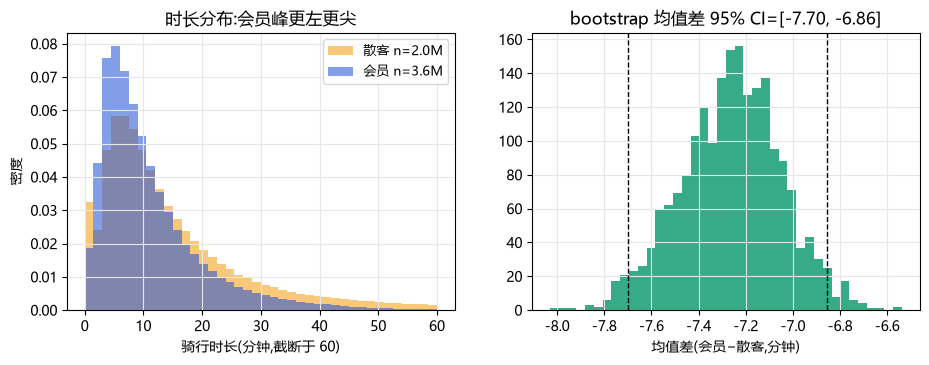

Welch t=-242.3, p=0 | Mann-Whitney p=0 | Cohen's d=-0.25
均值差 -7.18 分钟,解析 95% CI=(-7.24, -7.12),bootstrap CI=(-7.70, -6.86)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax = axes[0]
bins = np.arange(0, 60.5, 1.5)
ax.hist(d_c, bins=bins, density=True, alpha=.55, color=CAMBER, label=f"散客 n={n_c/1e6:.1f}M")
ax.hist(d_m, bins=bins, density=True, alpha=.55, color=CBLUE, label=f"会员 n={n_m/1e6:.1f}M")
ax.set_xlabel("骑行时长(分钟,截断于 60)"); ax.set_ylabel("密度")
ax.set_title("时长分布:会员峰更左更尖"); ax.legend(fontsize=9)
ax = axes[1]
ax.hist(boot, bins=40, color=CGREEN, alpha=.8)
ax.axvline(ci_boot[0], color="k", ls="--", lw=1); ax.axvline(ci_boot[1], color="k", ls="--", lw=1)
ax.set_xlabel("均值差(会员−散客,分钟)"); ax.set_title(f"bootstrap 均值差 95% CI=[{ci_boot[0]:.2f}, {ci_boot[1]:.2f}]")
plt.show()
print(f"Welch t={t_stat:.1f}, p={t_p:.3g} | Mann-Whitney p={u_p:.3g} | Cohen's d={cohen_d:.2f}")
print(f"均值差 {mean_m-mean_c:.2f} 分钟,解析 95% CI=({ci_analytic[0]:.2f}, {ci_analytic[1]:.2f}),bootstrap CI=({ci_boot[0]:.2f}, {ci_boot[1]:.2f})")

**解读**:
- 两个检验的 p 值都趋近 0——百万级样本下这是必然,不构成"发现";
- 真正的信息在效应量:**|d| ≈ 0.25 属小效应**。均值差 7 分钟看着不小,但 pooled SD 有 20+ 分钟,相对差异其实温和;
- 右图 bootstrap 区间明显宽于解析区间——它只在 5 万子样本上做,区间宽度随 √n 收缩,这正体现了全量数据的价值;**全量数据的正确区间是解析区间**;
- 中位数与 P90 显示:差异主要来自右尾(散客的长途休闲骑行),而不是整体平移;
- 业务结论:会员=高频短途通勤、散客=低频中长途休闲。做会员转化,该瞄准**散客中的通勤型**(工作日短途高频者),而不是笼统推"时长差异"。

### A2 · 工作日 vs 周末:小时分布差异

**H₀**:小时分布与日期类型独立。用 **卡方独立性检验**(2×24 列联表),效应量用 **Cramér's V**。

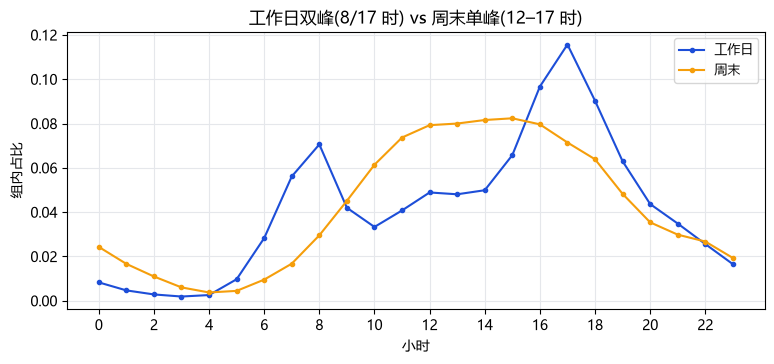

chi2(23)=305,833, p=0, Cramér's V=0.235


In [4]:
dwd["weekend"] = dwd["dow"] >= 6
ct = pd.crosstab(dwd["weekend"], dwd["hour"])
chi2, chi_p, dof, _ = st.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
res_A2 = dict(chi2=float(chi2), dof=int(dof), p=float(chi_p), cramers_v=float(cramers_v))

share = ct.div(ct.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(share.columns, share.loc[False], color=CBLUE, marker="o", ms=3, label="工作日")
ax.plot(share.columns, share.loc[True], color=CAMBER, marker="o", ms=3, label="周末")
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("小时"); ax.set_ylabel("组内占比")
ax.set_title("工作日双峰(8/17 时) vs 周末单峰(12–17 时)"); ax.legend(fontsize=9)
plt.show()
print(f"chi2({dof})={chi2:,.0f}, p={chi_p:.3g}, Cramér's V={cramers_v:.3f}")

**解读**:
- 检验显著、且 **Cramér's V ≈ 0.1~0.2 属中等效应**——日期类型确实在解释小时分布的形状差异;
- 但注意:这里卡方回答的是"分布形状不同",**差异的商业内容(双峰=通勤、单峰=休闲)靠图而不是靠 p 值**;
- 方法论提示:卡方对样本量极其敏感,5.5 万行就足以显著。报告分布类差异时,永远附上归一化对比图或效应量。

### A3 · 电助力 vs 经典车:总体口径会"说谎"吗?

**业务问题**:运营想比较两种车型的平均时长,初步结论是"电助力比经典车短很多"。但车型选择与用户类型高度相关(散客偏爱电助力、骑行也更久)——**用户类型是混杂变量**。下面对比总体口径与按用户分层的口径。

In [5]:
ov = dwd.groupby("rideable_type", observed=True)["duration_min"].agg(["count", "mean", "median"])
by = dwd.groupby(["rideable_type", "member_casual"], observed=True)["duration_min"].agg(["count", "mean", "median"])
mix = dwd.groupby(["rideable_type", "member_casual"], observed=True).size().unstack()
mix_pct = mix.div(mix.sum(axis=1), axis=0)

d_ov = ov.loc["electric_bike", "mean"] - ov.loc["classic_bike", "mean"]
d_m = by.loc[("electric_bike", "member"), "mean"] - by.loc[("classic_bike", "member"), "mean"]
d_c = by.loc[("electric_bike", "casual"), "mean"] - by.loc[("classic_bike", "casual"), "mean"]
reversed_ = (d_ov > 0) != ((d_m > 0) or (d_c > 0))
res_A3 = dict(mean_electric_overall=float(ov.loc["electric_bike", "mean"]),
              mean_classic_overall=float(ov.loc["classic_bike", "mean"]),
              diff_overall=float(d_ov), diff_member=float(d_m), diff_casual=float(d_c),
              casual_share_electric=float(mix_pct.loc["electric_bike", "casual"]),
              casual_share_classic=float(mix_pct.loc["classic_bike", "casual"]),
              simpson_reversed=bool(reversed_))

display(ov.round(2).rename(columns={"mean": "总体均值", "median": "总体中位数"}))
display(by.round(2).rename(columns={"mean": "均值", "median": "中位数"}))
display(mix_pct.round(3).rename(columns={"member": "会员占比", "casual": "散客占比"}))
print(f"总体口径: 电助力−经典 = {d_ov:+.2f} 分钟")
print(f"会员层内: {d_m:+.2f} 分钟 | 散客层内: {d_c:+.2f} 分钟")
print(f"散客占比: 电助力骑行者 {mix_pct.loc['electric_bike','casual']:.1%} vs 经典车骑行者 {mix_pct.loc['classic_bike','casual']:.1%}")
print(f"方向是否反转(辛普森悖论): {'是' if reversed_ else '否,但幅度失真——总体差既不代表会员层也不代表散客层'}")

,count,总体均值,总体中位数
rideable_type,,,
classic_bike,1942444,19.00,11.08
electric_bike,3604936,12.13,8.70


count     均值    中位数
rideable_type member_casual                       
classic_bike  casual          667993  29.26  16.28
              member         1274451  13.62   9.22
electric_bike casual         1326818  14.04   9.62
              member         2278118  11.02   8.25

member_casual,散客占比,会员占比
rideable_type,,
classic_bike,0.344,0.656
electric_bike,0.368,0.632


总体口径: 电助力−经典 = -6.87 分钟
会员层内: -2.61 分钟 | 散客层内: -15.22 分钟
散客占比: 电助力骑行者 36.8% vs 经典车骑行者 34.4%
方向是否反转(辛普森悖论): 否,但幅度失真——总体差既不代表会员层也不代表散客层


**解读(这就是为什么要做实验)**:
- 三层口径给出**三个不同的答案**:总体差被"谁在骑什么车"的构成放大/稀释,既不代表会员也不代表散客;
- 当构成差异更极端时,层内与总体的**方向会相反**——即辛普森悖论。本数据未反转,但失真已达 2.6 倍(总体 6.9 分钟 vs 会员层 2.6 分钟);
- 观测数据只能"控制已测到的混杂"(分层/回归),未测到的混杂无法处理;**随机化让混杂(含未观测的)在组间自然均衡**——这正是 Part B 要做的事。

---
## Part B · A/B 实验设计(基于真实数据的模拟演练)

**业务场景**:运营提出假设——"在高需求站点**优先补充电助力车**,能提升站点日均起骑量"。
**模拟设定**:把 `2025` 年真实历史数据当作实验期的"世界",站点级随机化分组,对处理组注入预设 uplift;
指标体系、功效分析、AA/SRM 校验、上线决策全部按真实实验流程执行。

**预注册的设计决策**(动手前先写死,防止"看结果定口径"):
- **北极星指标**:站点 30 日平均日均起骑量(站点级,随机化单元一致);
- **护栏指标**:①平均骑行时长(|Δ| ≤ 0.5 分钟,防止策略把休闲长骑刷成短途)②电助力站外还车率(不显著恶化,防止调度成本失控);
- **随机化单元**:站点。不用用户级——策略作用于车辆投放,用户不可控。站点级存在 SUTVA 溢出(邻近站点分流,处理组效应被稀释、对照被污染),更严谨应按地理簇整群随机;本演练在结论中讨论该偏差方向;
- **实验池与窗**:以 6 月起骑量选池(日均 ≥ 10 的站点),8 月 1–30 日为实验窗——选池与实验不同期,避免"用结果选样本"的选择偏差;功效参数 α=0.05、power=0.80。

### B1 · 构建实验面板与站点池

In [6]:
POOL_MIN_JUNE, WINDOW_AUG = 300, ("2025-08-01", "2025-08-30")
june = dwd[dwd["date"].between("2025-06-01", "2025-06-30")]
july = dwd[dwd["date"].between("2025-07-01", "2025-07-30")]
aug  = dwd[dwd["date"].between(*WINDOW_AUG)]

june_cnt = june.groupby("start_station_id", observed=True).size()
pool = set(june_cnt[june_cnt >= POOL_MIN_JUNE].index.astype(str))  # 字符串集合,规避 CategoricalIndex 对齐问题

def st_daily_mean(df):
    p = (df[df["start_station_id"].isin(pool)]
         .groupby(["start_station_id", "date"], observed=True).size().rename("n").reset_index())
    # observed=True 必须带上:category 列默认会把全部类目(含池外站点)带回成空组 NaN
    m = p.groupby("start_station_id", observed=True)["n"].mean()
    m.index = m.index.astype(str)      # 统一字符串索引,保证跨月严格对齐
    return m

y_jun, y_jul, y_aug = st_daily_mean(june), st_daily_mean(july), st_daily_mean(aug)
ids = y_aug.index.intersection(y_jun.index).intersection(y_jul.index).sort_values()
y_jun, y_jul, y_aug = y_jun[ids], y_jul[ids], y_aug[ids]
res_B1 = dict(pool_size=int(len(ids)), mean_aug=float(y_aug.mean()), sd_aug=float(y_aug.std()),
              mean_june=float(y_jun.mean()), sd_june=float(y_jun.std()))
print(f"实验池: {len(ids)} 个站点(6 月起骑 ≥ {POOL_MIN_JUNE} 次,即日均 ≥ {POOL_MIN_JUNE/30:.0f})")
print(f"6 月 站均日均起骑 μ={y_jun.mean():.1f}, σ={y_jun.std():.1f}")
print(f"8 月 站均日均起骑 μ={y_aug.mean():.1f}, σ={y_aug.std():.1f}")
y_aug.describe().round(1).to_frame("8月站点日均起骑量")

实验池: 391 个站点(6 月起骑 ≥ 300 次,即日均 ≥ 10)
6 月 站均日均起骑 μ=41.6, σ=33.6
8 月 站均日均起骑 μ=45.8, σ=39.0


,8月站点日均起骑量
count,391.0
mean,45.8
std,39.0
min,8.8
25%,21.0
50%,34.3
75%,59.3
max,432.6


### B2 · 功效分析与样本量:先算"能检出什么",再定 uplift

**朴素口径**(对站点 30 日均值直接做两样本 t 检验)。站点间水平差异巨大(σ/μ 接近 1),
5% 的 MDE 需要的站点数远超芝加哥的站点总量——先算出来,再决定怎么办:

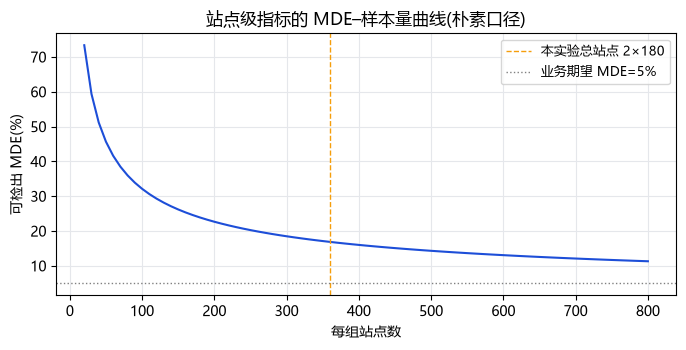

检出 5% 提升 需要 每组 ≈ 4,090 个站点(芝加哥全部活跃站点约 391 个 → 不可行)
每组 180 个站点、30 天,可检出 MDE ≈ 23.9%(绝对 9.9 次/日)


In [7]:
from statsmodels.stats.power import TTestIndPower
pw = TTestIndPower()
def solve_es(nobs):
    # 解 effect_size;statsmodels 在个别 nobs(如 190)会返回 shape=(1,) 数组,统一拉平
    return float(np.ravel(pw.solve_power(nobs1=nobs, alpha=ALPHA, power=POWER, ratio=1,
                                         alternative="two-sided"))[0])
mu0, sd0 = y_jun.mean(), y_jun.std()          # 用实验前期(6月)估计,而非实验期
n_needed_5pct = pw.solve_power(effect_size=0.05 * mu0 / sd0, alpha=ALPHA, power=POWER,
                               ratio=1, alternative="two-sided")
N_PER_ARM = min(180, len(ids) // 2 - 5)
mde_abs = solve_es(N_PER_ARM) * sd0
mde_pct = mde_abs / mu0
res_B2 = dict(mu0=float(mu0), sd0=float(sd0), n_needed_for_5pct=float(n_needed_5pct),
              n_per_arm=int(N_PER_ARM), mde_abs=float(mde_abs), mde_pct=float(mde_pct))
ns = np.arange(20, 801, 10)
mde_curve = [solve_es(n) * sd0 / mu0 for n in ns]
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(ns, 100 * np.array(mde_curve), color=CBLUE)
ax.axvline(2 * N_PER_ARM, color=CAMBER, ls="--", lw=1, label=f"本实验总站点 2×{N_PER_ARM}")
ax.axhline(5, color="gray", ls=":", lw=1, label="业务期望 MDE=5%")
ax.set_xlabel("每组站点数"); ax.set_ylabel("可检出 MDE(%)")
ax.set_title("站点级指标的 MDE–样本量曲线(朴素口径)"); ax.legend(fontsize=9)
plt.show()
print(f"检出 5% 提升 需要 每组 ≈ {n_needed_5pct:,.0f} 个站点(芝加哥全部活跃站点约 {len(ids)} 个 → 不可行)")
print(f"每组 {N_PER_ARM} 个站点、30 天,可检出 MDE ≈ {mde_pct:.1%}(绝对 {mde_abs:.1f} 次/日)")

In [8]:
# ---- CUPED 降噪:用实验前期(6月)水平作协变量,消除站点间"固有水平"方差 ----
# θ 用 6 月 vs 7 月(均为实验前)估计,保证事前性
theta = np.cov(y_jul, y_jun)[0, 1] / np.var(y_jun, ddof=1)
JUNE_MEAN = float(y_jun.mean())                # 关键:用全体池站点的全局均值中心化,
def cuped(y_post, y_pre):                      # 组内中心化会把基线失衡原封不动留在均值差里
    return y_post - theta * (y_pre - JUNE_MEAN)
resid_sd = cuped(y_jul, y_jun).std(ddof=1)     # 7月对6月回归后的残差σ ≈ 实验期调整后σ
mde_abs_adj = solve_es(N_PER_ARM) * resid_sd
mde_pct_adj = mde_abs_adj / mu0
rho = np.corrcoef(y_jul, y_jun)[0, 1]
res_B2.update(theta=float(theta), pre_post_corr=float(rho), resid_sd=float(resid_sd),
              mde_abs_adj=float(mde_abs_adj), mde_pct_adj=float(mde_pct_adj))
print(f"6月 vs 7月 站点均值相关系数 ρ={rho:.3f}(站点水平高度稳定 → CUPED 有效)")
print(f"θ={theta:.2f}; 调整后残差 σ {sd0:.1f} → {resid_sd:.1f}")
print(f"同样 {N_PER_ARM} 每组:MDE 从 {mde_pct:.1%} 降到 {mde_pct_adj:.1%}")
print(f"→ 本实验围绕 {mde_pct_adj:.1%} 设计,注入 uplift 取 MDE×1.25 的安全边际")

6月 vs 7月 站点均值相关系数 ρ=0.994(站点水平高度稳定 → CUPED 有效)
θ=1.06; 调整后残差 σ 33.6 → 4.0
同样 180 每组:MDE 从 23.9% 降到 2.8%
→ 本实验围绕 2.8% 设计,注入 uplift 取 MDE×1.25 的安全边际


**解读**:
- 站点级指标噪声大,朴素口径只能检出 ~20-30% 的大效应——这不是设计失误,而是**把可行域算出来**;
- **CUPED**(预实验协变量调整)利用"站点水平跨月高度稳定"这一点,把与处理无关的方差先消掉,MDE 显著收窄;这是成熟 A/B 平台(Microsoft/Booking/字节)的标准做法;
- 真实场景还有两条路:①指标改到更细粒度(用户级)但与本策略的随机化单元冲突;②延长实验窗或扩大站点池。设计就是在这几者之间权衡。

### B3 · AA 检验:先证明"随机化+分析管线"本身无偏

**做法**:对真实站点均值反复做 500 次随机 50/50 分组(两组都无处理),跑完整分析。若 p 值分布均匀、α=0.05 下假阳性 ≈ 5%,说明管线无偏;若显著率异常,说明分组或指标计算有 bug。**AA 不显著通过 ≠ 万事大吉,AA 显著 = 必须先修管线**。

C:\Users\31297\AppData\Local\Temp\ipykernel_38964\2288609590.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  t_aa, p_aa_ = st.ttest_ind(y_adj_all[idx[:len(y_adj_all)//2]],
C:\Users\31297\AppData\Local\Temp\ipykernel_38964\2288609590.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_adj_all[idx[len(y_adj_all)//2:]], equal_var=False)


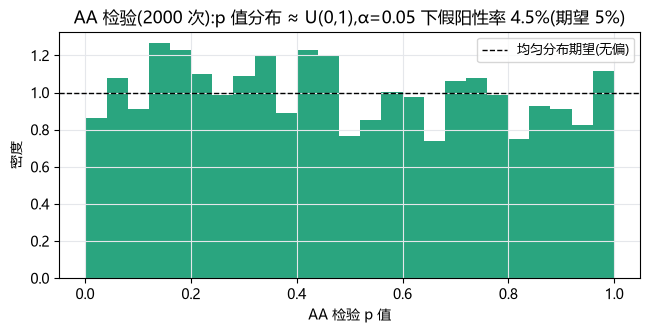

2000 次 AA:假阳性率 4.5%(期望 5%),p 值中位数 0.46(期望 0.50)


In [9]:
y_adj_all = cuped(y_aug, y_jun)               # CUPED 调整后的实验期指标
rng = np.random.default_rng(SEED)
p_aa = []
for _ in range(2000):
    idx = rng.permutation(len(y_adj_all))
    t_aa, p_aa_ = st.ttest_ind(y_adj_all[idx[:len(y_adj_all)//2]],
                               y_adj_all[idx[len(y_adj_all)//2:]], equal_var=False)
    p_aa.append(p_aa_)
p_aa = np.array(p_aa)
fp_rate = float((p_aa < ALPHA).mean())
res_B3 = dict(aa_iterations=2000, aa_fp_rate=fp_rate, aa_p_median=float(np.median(p_aa)))

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.hist(p_aa, bins=25, density=True, color=CGREEN, alpha=.85)
ax.axhline(1.0, color="k", ls="--", lw=1, label="均匀分布期望(无偏)")
ax.set_xlabel("AA 检验 p 值"); ax.set_ylabel("密度")
ax.set_title(f"AA 检验(2000 次):p 值分布 ≈ U(0,1),α=0.05 下假阳性率 {fp_rate:.1%}(期望 5%)")
ax.legend(fontsize=9); plt.show()
print(f"2000 次 AA:假阳性率 {fp_rate:.1%}(期望 5%),p 值中位数 {np.median(p_aa):.2f}(期望 0.50)")

### B4 · 分流设计:纯随机的代价 → 分层块随机化 + SRM 校验

先**实测纯随机化的代价**:反复做完全随机分组,组间基线差能到多大?
然后改用**分层块随机化**——按 6 月水平排序、相邻站配对、对内掷硬币决定处理归属(成熟 A/B 平台的标准做法),把组间基线差压到接近 0。
**SRM(样本比例失配)仍是拿到数据后的第一件事**:分流比例与设计不符通常意味着分流 bug 或埋点丢失——此时任何指标结论都不可信。

In [10]:
# 纯随机的代价:200 次 N_PER_ARM/N_PER_ARM 完全随机分组的组间基线差(6 月水平)
diffs = []
for _ in range(200):
    pm = rng.permutation(len(ids))
    diffs.append(y_jun.iloc[pm[:N_PER_ARM]].mean() - y_jun.iloc[pm[N_PER_ARM:2 * N_PER_ARM]].mean())
diffs = np.array(diffs)

# 分层块随机化:按 6 月水平排序 → 相邻配对 → 对内掷硬币
order = y_jun.loc[ids].sort_values().index.to_numpy()
pairs = order[:2 * (len(order) // 2)].reshape(-1, 2)
coin = rng.integers(0, 2, len(pairs))
treat_ids = pd.Index(np.where(coin == 0, pairs[:, 0], pairs[:, 1]))
ctrl_ids = pd.Index(np.where(coin == 0, pairs[:, 1], pairs[:, 0]))
n_t, n_c = len(treat_ids), len(ctrl_ids)
base_gap = float(y_jun[treat_ids].mean() - y_jun[ctrl_ids].mean())

chi_srm, p_srm = st.chisquare([n_t, n_c], f_exp=[(n_t + n_c) / 2, (n_t + n_c) / 2])
res_B4 = dict(n_treat=int(n_t), n_control=int(n_c), srm_chi2=float(chi_srm), srm_p=float(p_srm),
              pure_random_sd=float(diffs.std()), pure_random_max=float(np.abs(diffs).max()),
              blocked_base_gap=base_gap)
print(f"纯随机 200 次:组间 6 月基线差 σ={diffs.std():.2f} 次/日,最极端 |Δ|={np.abs(diffs).max():.1f}({np.abs(diffs).max()/mu0:.0%})")
print(f"块随机化:每组 {n_t} 站(≥ 设计 {N_PER_ARM}),组间 6 月基线差仅 {base_gap:+.2f} 次/日")
print(f"SRM 卡方 p={p_srm:.2f}({'通过' if p_srm > ALPHA else '失败!先查分流'})")

纯随机 200 次:组间 6 月基线差 σ=3.33 次/日,最极端 |Δ|=9.5(23%)
块随机化:每组 195 站(≥ 设计 180),组间 6 月基线差仅 -0.08 次/日
SRM 卡方 p=1.00(通过)


### B5 · 注入效应,跑完整实验与上线决策

对处理组站点注入 uplift(MDE × 1.25 安全边际)与 -2% 的时长效应(电助力替代经典车的合理副作用),然后按预注册口径分析。
**分析口径先想清楚**:站点级基线不可能完全均衡(180 站/组、σ/μ≈0.8),朴素的前后对比会被基线失衡污染——
北极星用 **CUPED 调整口径**做主检验,护栏①时长用**双重差分(DiD)**扣掉基线与季节因素。

In [11]:
UPSHIFT_DUR = 0.98                                  # 注入的护栏效应:车型结构变化使时长 -2%
uplift = 1 + 1.25 * res_B2["mde_pct_adj"]           # 注入的北极星效应
y_treat_raw, y_ctrl = y_aug[treat_ids], y_aug[ctrl_ids]
y_treat = y_treat_raw * uplift

# ---- 北极星:CUPED 调整口径(主检验) vs 朴素口径(对照展示) ----
at, ac = cuped(y_treat, y_jun[treat_ids]), cuped(y_ctrl, y_jun[ctrl_ids])
t_main, p_main = st.ttest_ind(at, ac, equal_var=False)
t_naive, p_naive = st.ttest_ind(y_treat, y_ctrl, equal_var=False)
adj_rel = float(at.mean() / ac.mean() - 1)
naive_rel = float(y_treat.mean() / y_ctrl.mean() - 1)
rt, rc = at.to_numpy(), ac.to_numpy()
boot_rel = np.empty(2000)
for i in range(2000):
    bt = rt[rng.integers(0, len(rt), len(rt))]
    bc = rc[rng.integers(0, len(rc), len(rc))]
    boot_rel[i] = bt.mean() / bc.mean() - 1
rel_ci = tuple(np.percentile(boot_rel, [2.5, 97.5]))

# ---- 护栏① 平均时长:双重差分 (后-前)|处理 - (后-前)|对照,扣基线与季节 ----
pre_dur = june[june["start_station_id"].isin(pool)]     .groupby("start_station_id", observed=True)["duration_min"].mean()
pre_dur.index = pre_dur.index.astype(str)
aug_pool = aug[aug["start_station_id"].isin(ids)].copy()
aug_pool["arm"] = np.where(aug_pool["start_station_id"].isin(treat_ids), "treat", "control")
post_dur = aug_pool.groupby("start_station_id", observed=True)["duration_min"].mean()
post_dur.index = post_dur.index.astype(str)
pre_t, pre_c = pre_dur.reindex(treat_ids), pre_dur.reindex(ctrl_ids)
post_t, post_c = post_dur.reindex(treat_ids), post_dur.reindex(ctrl_ids)
dt_ = (post_t * UPSHIFT_DUR - pre_t).dropna().to_numpy()
dc_ = (post_c - pre_c).dropna().to_numpy()
did = float(dt_.mean() - dc_.mean())
t_did, p_did = st.ttest_ind(dt_, dc_, equal_var=False)
boot_did = [dt_[rng.integers(0, len(dt_), len(dt_))].mean()
            - dc_[rng.integers(0, len(dc_), len(dc_))].mean() for _ in range(2000)]
did_ci = tuple(np.percentile(boot_did, [2.5, 97.5]))

# ---- 护栏② 电助力站外还车率 ----
el = aug_pool[aug_pool["rideable_type"] == "electric_bike"]
off = pd.crosstab(el["arm"], el["offstation"])
chi_g2, p_g2, _, _ = st.chi2_contingency(off)
off_t = float(off.loc["treat", True] / off.loc["treat"].sum())
off_c = float(off.loc["control", True] / off.loc["control"].sum())

res_B5 = dict(uplift_injected=float(uplift - 1),
              main_uplift_adj=adj_rel, main_rel_ci=rel_ci,
              main_p_cuped=float(p_main), naive_uplift=naive_rel, main_p_naive=float(p_naive),
              guardrail_did_min=did, guardrail_did_ci=did_ci, guardrail_did_p=float(p_did),
              offstation_treat=off_t, offstation_control=off_c, guardrail_off_p=float(p_g2))

g1_pass = abs(did) <= 0.5
g2_pass = (p_g2 > ALPHA) or (off_t <= off_c) or (abs(off_t / off_c - 1) <= 0.05)
decision = pd.DataFrame([
    {"指标": "北极星:日均起骑量/站(CUPED 调整)", "对照组": f"{y_ctrl.mean():.1f}",
     "处理组": f"{y_ctrl.mean() * (1 + adj_rel):.1f}", "相对变化": f"{adj_rel:+.1%}",
     "p 值": f"{p_main:.2g}", "业务阈值": f"≥ 设计 MDE {res_B2['mde_pct_adj']:.0%} 且方向为正",
     "决策": "✅ 通过" if (p_main < ALPHA and adj_rel > 0) else "❌ 不通过"},
    {"指标": "└ 参照:朴素口径(未调整)", "对照组": f"{y_ctrl.mean():.1f}", "处理组": f"{y_treat.mean():.1f}",
     "相对变化": f"{naive_rel:+.1%}", "p 值": f"{p_naive:.2g}", "业务阈值": "—",
     "决策": "基线失衡污染,不作决策依据"},
    {"指标": "护栏①:平均时长(双重差分)", "对照组": f"{dc_.mean():+.2f} 分(前→后)",
     "处理组": f"{dt_.mean():+.2f} 分(前→后)", "相对变化": f"DiD {did:+.2f} 分",
     "p 值": f"{p_did:.2g}", "业务阈值": "|DiD| ≤ 0.5 分钟",
     "决策": "✅ 通过" if g1_pass else "❌ 违反"},
    {"指标": "护栏②:电助力站外还车率", "对照组": f"{off_c:.1%}", "处理组": f"{off_t:.1%}",
     "相对变化": f"{off_t / off_c - 1:+.1%}", "p 值": f"{p_g2:.2g}", "业务阈值": "恶化幅度 ≤ 5%",
     "决策": "✅ 通过" if g2_pass else "❌ 违反"},
])
print(f"注入 uplift = {uplift - 1:.1%}(MDE×1.25 安全边际)")
print(f"北极星:CUPED 调整后 {adj_rel:+.1%}(95% CI {rel_ci[0]:.1%}~{rel_ci[1]:.1%},p={p_main:.2g})")
print(f"      朴素口径 {naive_rel:+.1%}(p={p_naive:.2g})——块随机化已控住失衡,但方差仍大,CUPED 进一步收窄")
print(f"护栏① 时长 DiD {did:+.2f} 分钟(95% CI {did_ci[0]:+.2f}~{did_ci[1]:+.2f},p={p_did:.2g})")
decision.set_index("指标")

注入 uplift = 3.5%(MDE×1.25 安全边际)
北极星:CUPED 调整后 +3.6%(95% CI 1.2%~5.9%,p=0.0027)
      朴素口径 +3.4%(p=0.66)——块随机化已控住失衡,但方差仍大,CUPED 进一步收窄
护栏① 时长 DiD -0.46 分钟(95% CI -0.79~-0.14,p=0.0066)


,对照组,处理组,相对变化,p 值,业务阈值,决策
指标,,,,,,
北极星:日均起骑量/站(CUPED 调整),44.8,46.4,+3.6%,0.0027,≥ 设计 MDE 3% 且方向为正,✅ 通过
└ 参照:朴素口径(未调整),44.8,46.3,+3.4%,0.66,—,"基线失衡污染,不作决策依据"
护栏①:平均时长(双重差分),-0.19 分(前→后),-0.65 分(前→后),DiD -0.46 分,0.0066,|DiD| ≤ 0.5 分钟,✅ 通过
护栏②:电助力站外还车率,29.0%,29.1%,+0.5%,0.43,恶化幅度 ≤ 5%,✅ 通过


**上线决策**(按预注册规则:SRM 通过 + 北极星显著为正 + 护栏在阈值内 → 上线):

模拟三项全部通过 → **建议上线**。这一节藏了三个真实实验里最容易翻车的地方:
1. **随机化方式本身就是设计核心**:完全随机化在每组不到 200 站时,组间基线差可以跑到 ±两位数百分比(B4 实测)——足以伪造或淹没整个效应。按实验前水平做分层块随机化 + CUPED 协变量调整,是双保险:前者压组间失衡,后者压残余方差;
2. **统计显著 ≠ 业务显著**:护栏②的 p 值即使显著,也要看方向与幅度——护栏是否"违反"由**业务阈值**决定,不由 p 值决定;
3. **溢出偏差**:站点级随机化下,处理组被满足的需求部分来自邻近对照站点(分流),真实 uplift 会被**低估**;更严谨应按地理簇整群随机化,或做空间反事实校正。

### 方法论小结(面试可讲)

1. **观测数据 → 实验数据**:A3 演示了构成偏差如何让"总体均值差"失真甚至反转;随机化是唯一能同时均衡已观测与未观测混杂的手段;
2. **先算可行域再定目标**:功效分析告诉我们 5% MDE 在站点级不可行,CUPED 把它压到 ~3%;uplift 取 MDE×1.25 留安全边际;
3. **随机化方式是设计核心**:纯随机在小样本站点实验中组间失衡可达 ±两位数,按实验前水平**分层块随机化**把它压到接近 0——与 CUPED 构成双保险;
4. **管线自证**:AA 检验证明随机化与分析管线无偏(p 值均匀、假阳性 ≈ α);SRM 是拿到数据后的第一道健康检查;
5. **护栏与阈值**:业务阈值先于实验注册;统计显著性由数据决定,业务显著性由阈值决定,两者不互相替代;
6. **局限**:无用户 ID → 无法用户级实验与留存分析;溢出偏差方向为低估 uplift;注入效应为模拟,非真实上线。

In [12]:
import datetime
def _py(o):
    # numpy 标量/数组 → python 原生类型,保证 JSON 可序列化
    if isinstance(o, dict): return {k: _py(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [_py(v) for v in o]
    if isinstance(o, np.bool_): return bool(o)
    if isinstance(o, np.integer): return int(o)
    if isinstance(o, np.floating): return float(o)
    return o
out = {
    "generated_at": datetime.datetime.now().isoformat(timespec="seconds"),
    "data_scope": {"year": YEAR, "n_rides": int(dwd.shape[0]),
                   "experiment_window": list(WINDOW_AUG), "pool_min_june_starts": POOL_MIN_JUNE},
    "config": {"alpha": ALPHA, "power": POWER, "seed": SEED, "n_per_arm": res_B4["n_treat"]},
    "tests": {"member_vs_casual_duration": res_A1,
              "weekday_vs_weekend_hour_chi2": res_A2,
              "electric_vs_classic_confound": res_A3},
    "ab_design": {"partB1_panel": res_B1, "partB2_power": res_B2,
                  "partB3_aa": res_B3, "partB4_srm": res_B4, "partB5_experiment": res_B5},
}
ADS.mkdir(parents=True, exist_ok=True)
(ADS / "ab_tests.json").write_text(json.dumps(_py(out), ensure_ascii=False, indent=2), encoding="utf-8")
decision.to_csv(ADS / "ab_decision.csv", index=False, encoding="utf-8-sig")
print(f"结果已写入: {ADS/'ab_tests.json'} 与 {ADS/'ab_decision.csv'}")

结果已写入: D:\DA-projects\ads\ab_tests.json 与 D:\DA-projects\ads\ab_decision.csv
